In [1]:
import pandas as pd

import scarf

scarf.configure_output(level="ERROR", progress=False)

repository = scarf.cytebase.connect("scarf_docs")
ctrl_path = repository.download_dataset(
    name="kang_15K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
stim_path = repository.download_dataset(
    name="kang_14K_ifnb-pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)

ds_ctrl = scarf.DataStore(f"{ctrl_path}/data.zarr", nthreads=4)
ds_stim = scarf.DataStore(f"{stim_path}/data.zarr", nthreads=4)

In [2]:
pd.DataFrame(
    [
        {
            "source": label,
            "assay": type(store.RNA).__name__,
            "cells": store.cells.N,
            "active cells": int(store.cells.fetch_all("I").sum()),
            "features": store.RNA.feats.N,
        }
        for label, store in (("ctrl", ds_ctrl), ("stim", ds_stim))
    ]
)

,source,assay,cells,active cells,features
0,ctrl,RNAassay,8487,8486,35635
1,stim,RNAassay,10111,10111,35635


In [3]:
merged_path = "scarf_datasets/kang_dataset_merging.zarr"
scarf.DataStoreMerge(
    datasets=[ds_ctrl, ds_stim],
    zarr_path=merged_path,
    names=["ctrl", "stim"],
    assays=["RNA"],
    prepend_text="orig",
    reset_cell_filter=False,
    source_column="sample_id",
    overwrite=True,
).dump()

merged = scarf.DataStore(merged_path, nthreads=4)

In [4]:
merged.cells.to_pandas_dataframe(
    ["sample_id", "orig_cluster_labels"],
    key="I",
).groupby("sample_id")["orig_cluster_labels"].agg(
    cells="count",
    cell_types="nunique",
)

,cells,cell_types
sample_id,,
ctrl,8486,13
stim,10111,13


In [5]:
prepared_path = repository.download_dataset(
    name="kang_29K_ctrl-ifnb_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(f"{prepared_path}/data.zarr", nthreads=4)
baseline = ds.pipeline.open(label="docs_default")
sorted(baseline)

['analysis_cell_selection',
 'ann_index',
 'cluster_selection',
 'clusters',
 'connectivity_map',
 'embedding_initialization',
 'feature_universe',
 'highly_variable_features',
 'input_cell_selection',
 'leiden_1.0',
 'neighbors',
 'normalized',
 'pca',
 'umap']

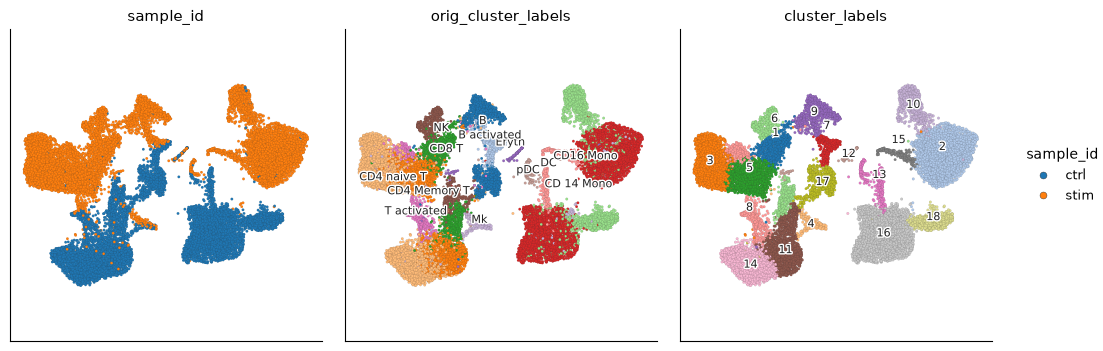

In [6]:
ds.plots.embedding(
    layout=baseline["umap"],
    color_by=["sample_id", "orig_cluster_labels", baseline["clusters"]],
    n_columns=3,
)

In [7]:
pd.crosstab(
    baseline.cells.fetch("clusters"),
    baseline.cells.fetch("sample_id"),
    normalize="index",
)

col_0,ctrl,stim
row_0,,
1,0.007924,0.992076
2,0.003753,0.996247
3,0.002387,0.997613
4,0.416244,0.583756
5,0.003844,0.996156
6,0.434896,0.565104
7,0.590323,0.409677
8,0.431853,0.568147
9,0.005875,0.994125


In [8]:
uncorrected_ilisi = ds.metric_ilisi(
    batch_colname="sample_id",
    neighbors=baseline["neighbors"],
    perplexity=7,
)
{"uncorrected iLISI": round(uncorrected_ilisi, 3)}

{'uncorrected iLISI': 0.0}